# House Price Prediction

## Project Overview
In this project, i will predict house prices in California
using Machine Learning models based on various features.

### Models Used:
- Linear Regression
- Random Forest
- XGBoost

### Dataset:
- California Housing Dataset (built-in from scikit-learn)

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load the dataset
housing = fetch_california_housing()

# Convert to DataFrame (table format)
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column (House Price)
df['MedHouseVal'] = housing.target

# Check first 10 rows
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [ ]:
print(housing.DESCR)    #read documentaion

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [ ]:
# size of data dataset
print("Shape of dataset:", df.shape)

Shape of dataset: (20640, 9)


In [ ]:
df.info()  #to check Number of raws,null value and data type of column

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.describe()  #statistical summary of a Dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


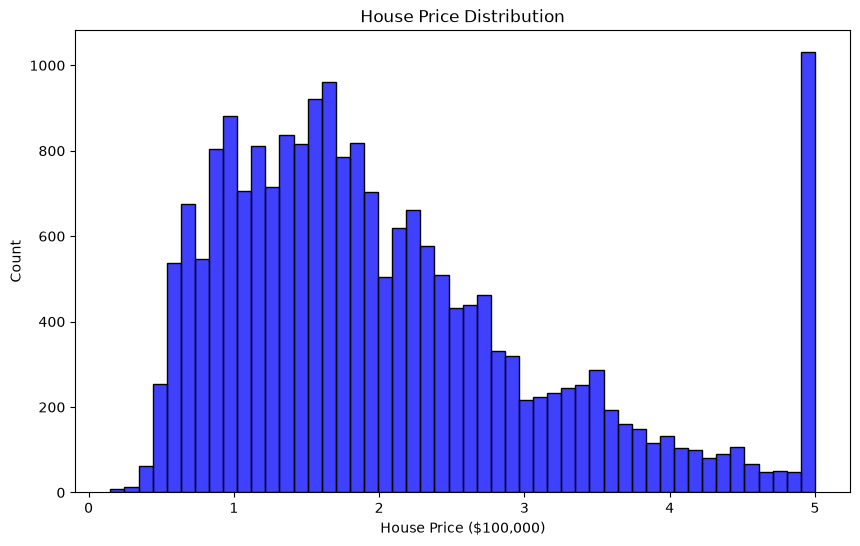

In [7]:
# Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['MedHouseVal'], bins=50, color='blue')
plt.title('House Price Distribution')
plt.xlabel('House Price ($100,000)')
plt.ylabel('Count')
plt.show()

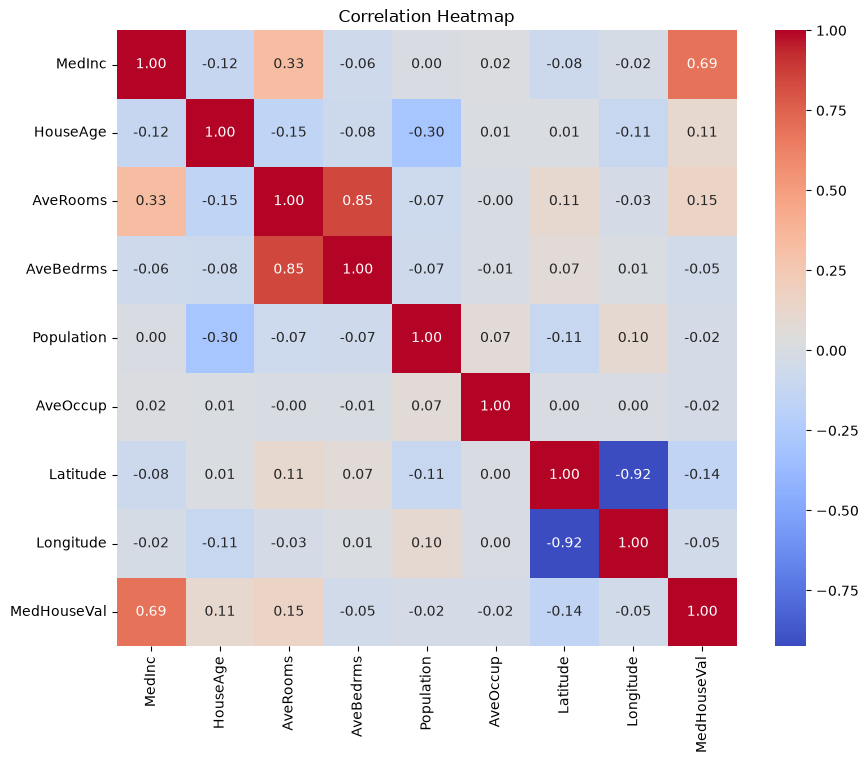

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

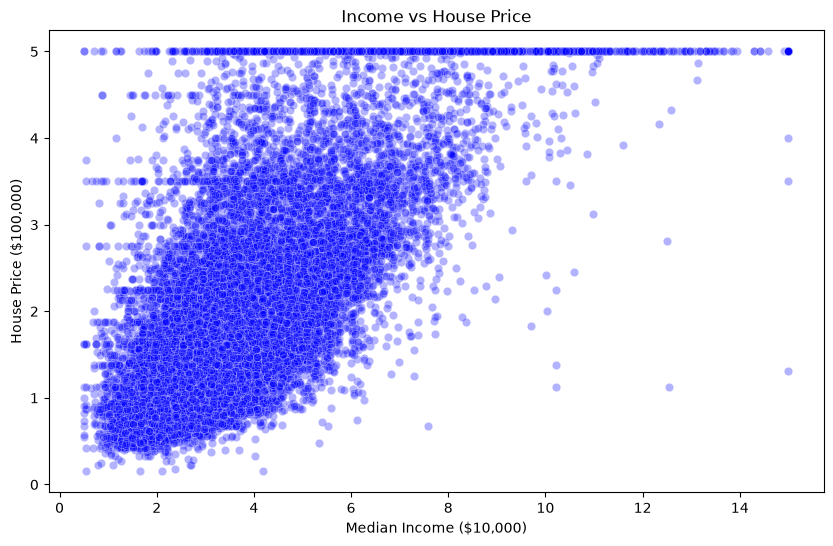

In [9]:
# Income vs House Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['MedInc'], 
                y=df['MedHouseVal'], 
                alpha=0.3,
                color='blue')
plt.title('Income vs House Price')
plt.xlabel('Median Income ($10,000)')
plt.ylabel('House Price ($100,000)')
plt.show()

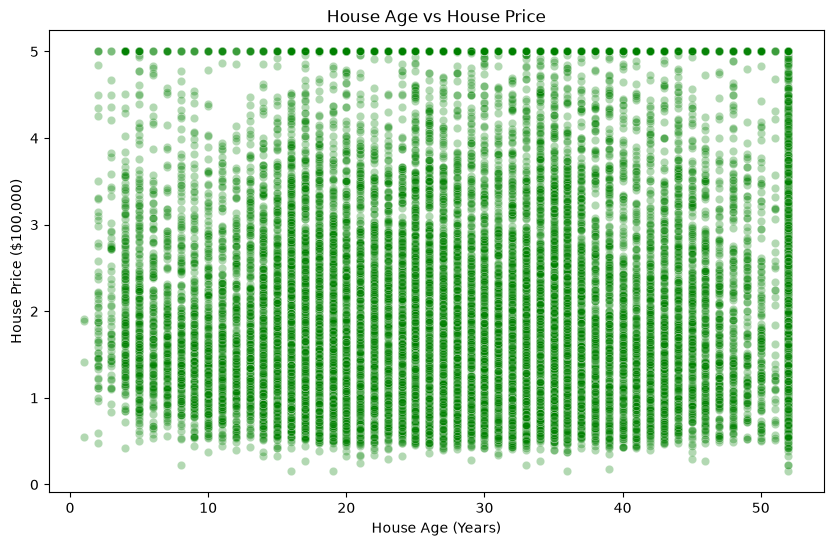

In [10]:
# HouseAge vs House Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['HouseAge'], 
                y=df['MedHouseVal'], 
                alpha=0.3,
                color='green')
plt.title('House Age vs House Price')
plt.xlabel('House Age (Years)')
plt.ylabel('House Price ($100,000)')
plt.show()

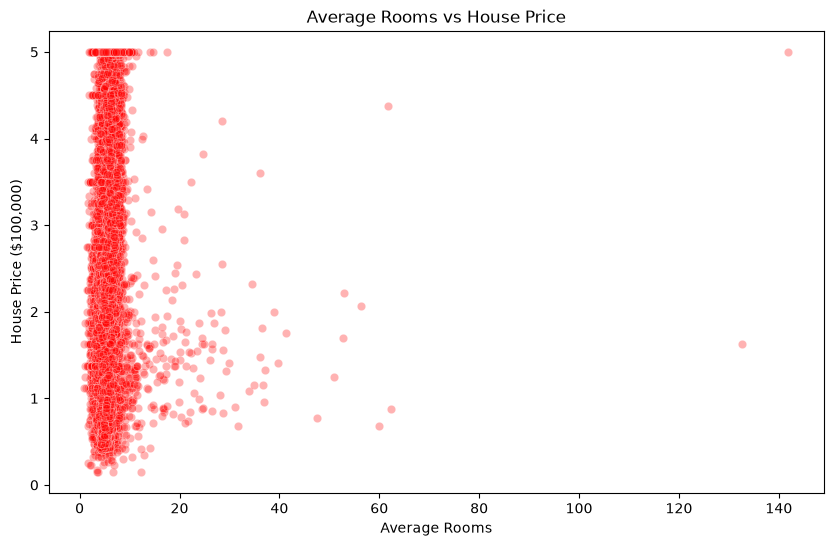

In [11]:
# AveRooms vs House Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['AveRooms'], 
                y=df['MedHouseVal'], 
                alpha=0.3,
                color='red')
plt.title('Average Rooms vs House Price')
plt.xlabel('Average Rooms')
plt.ylabel('House Price ($100,000)')
plt.show()

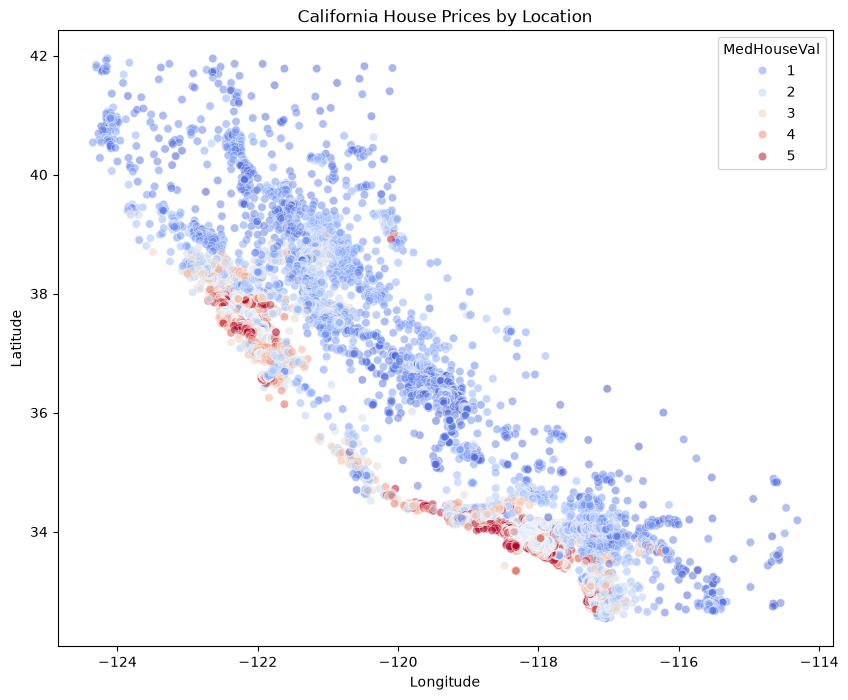

In [ ]:
# Location vs House Price   
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df['Longitude'], 
                y=df['Latitude'],
                hue=df['MedHouseVal'],
                palette='coolwarm',
                alpha=0.5)
plt.title('California House Prices by Location')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

**Los Angeles is located at a latitude of 34.0522° N and a longitude of -118.2437° W.**
**San Francisco is located at approximately 37.7749° N latitude and -122.4194° W longitude**

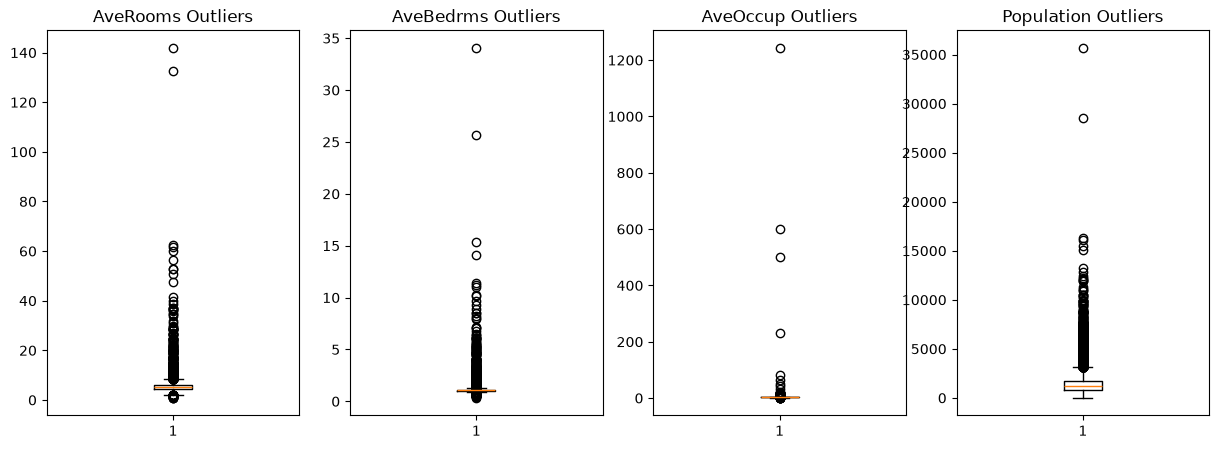

In [ ]:
# Outliers 
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# AveRooms
axes[0].boxplot(df['AveRooms'])
axes[0].set_title('AveRooms Outliers')

#AveBedrms
axes[1].boxplot(df['AveBedrms'])
axes[1].set_title('AveBedrms Outliers')

# AveOccup
axes[2].boxplot(df['AveOccup'])
axes[2].set_title('AveOccup Outliers')

# Population
axes[3].boxplot(df['Population'])
axes[3].set_title('Population Outliers')

plt.show()

In [ ]:
# function to remove outliers
def remove_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df = remove_outliers(df, 'AveRooms')
df = remove_outliers(df, 'AveOccup')
df = remove_outliers(df, 'Population')
df = remove_outliers(df, 'AveBedrms')
print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (17278, 9)


In [ ]:
# Cap values remove 
df = df[df['MedHouseVal'] < 5.0]
print("Shape after removing cap:", df.shape)

Shape after removing cap: (16494, 9)


In [16]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16494.000000,16494.000000,16494.000000,16494.000000,16494.000000,16494.000000,16494.000000,16494.000000,16494.000000
mean,3.725309,29.421547,5.183210,1.046274,1265.904268,2.864640,35.665389,-119.625400,1.961307
std,1.548405,12.215684,1.067335,0.066121,620.595030,0.623822,2.137763,1.994472,0.979606
min,0.536000,1.000000,2.032738,0.864286,5.000000,1.161290,32.540000,-124.350000,0.149990
25%,2.572625,19.000000,4.436659,1.002005,812.000000,2.437529,33.930000,-121.820000,1.193000
50%,3.519950,30.000000,5.158210,1.042927,1158.000000,2.815513,34.280000,-118.590000,1.793000
75%,4.644425,38.000000,5.882287,1.087952,1630.000000,3.243647,37.730000,-118.030000,2.538750
max,15.000100,52.000000,8.461538,1.234991,3093.000000,4.567164,41.950000,-114.570000,4.991000


In [ ]:
df.duplicated().sum()  #to see dublicate values in data

np.int64(0)

In [ ]:
#creat useful features through Existing data 
df['RoomsPerBedroom'] = df['AveRooms'] / df['AveBedrms']
df['BedroomRatio'] = df['AveBedrms'] / df['AveRooms']

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  RoomsPerBedroom  BedroomRatio  
0    -122.23        4.526         6.821705      0.146591  
1    -122.22        3.585         6.418626      0.155797  
2    -122.24        3.521         7.721053      0.129516  
3    -122.25        3.413         5.421277      0.184458  
4    -122.25        3.422         5.810714      0.172096  


In [19]:
df.shape

(16494, 11)

In [ ]:

from sklearn.preprocessing import StandardScaler

# split Features aur Target 
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Scaler 
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Scaling complete! ✅")

X shape: (16494, 10)
y shape: (16494,)
Scaling complete! ✅


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

print("Training complete! ✅")
print("X_train shape:", x_train.shape)
print("X_test shape:", x_test.shape)

Training complete! ✅
X_train shape: (13195, 10)
X_test shape: (3299, 10)


In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_predict))
r2 = r2_score(y_test, y_predict)

print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 0.5665
R2 Score: 0.6629


In [ ]:
# Random Forest Model
from sklearn.ensemble import RandomForestRegressor

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#  create Model 
rf_model = RandomForestRegressor(criterion="squared_error", max_depth=None, random_state=42)

# Train model
rf_model.fit(x_train, y_train)

# Predict 
y_pred_rf = rf_model.predict(x_test)

# Evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2 Score: {r2_rf:.4f}")

Random Forest Results:
RMSE: 0.4428
R2 Score: 0.7941


In [ ]:
from xgboost import XGBRegressor

# create model
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

# Train
xgb_model.fit(x_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(x_test)

# Evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R2 Score: {r2_xgb:.4f}")

XGBoost Results:
RMSE: 0.3819
R2 Score: 0.8468


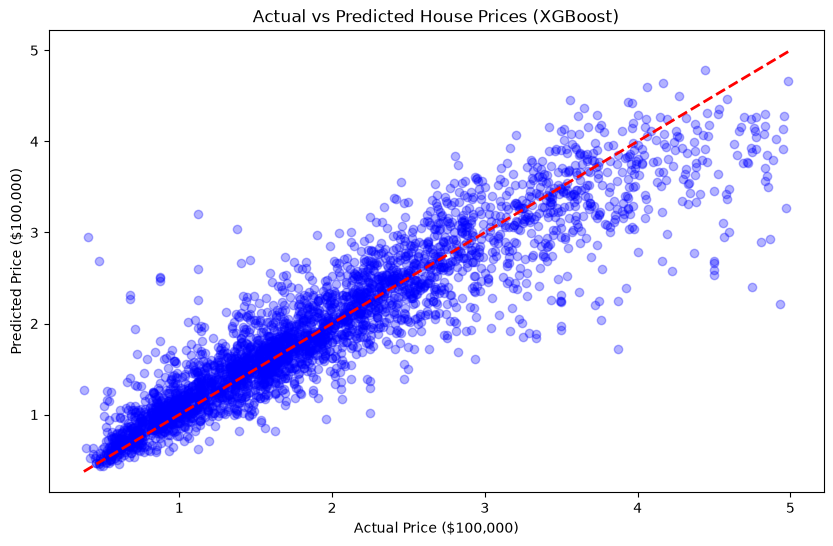

In [32]:
# Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.title('Actual vs Predicted House Prices (XGBoost)')
plt.xlabel('Actual Price ($100,000)')
plt.ylabel('Predicted Price ($100,000)')
plt.show()